# sfig1 — Cross-Cohort Replication Check (Supplementary Fig. S-1)

Checks whether the AUROC-vs-context-length pattern seen pooled across all four
cohorts also holds up **within** each cohort separately (APPLES, STAGES, MrOS,
SHHS), for the model trained on the pooled training set.

**Source**: collected/predictions/*.parquet (K='all' mean-prob aggregation, grouped by `dataset`)
**Tasks**: apnea, sleep efficiency, BMI, age, sex
**Note**: this is an in-distribution subgroup-consistency check, not external
validation — the model was trained on subjects pooled across all four cohorts.
See `markdown/SCALING_LAW_ANALYSIS_IDEAS.md` (Idea A) for the full writeup.


In [2]:
%matplotlib inline

In [3]:
import sys
from pathlib import Path

# ── Workspace root: auto-detect by looking for final_results/ ─────────────────
def _find_workspace():
    """Walk up from CWD until we find a directory containing final_results/."""
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    # Explicit fallback (edit this if auto-detect fails)
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
FINAL_RESULTS  = WORKSPACE_ROOT / "final_results"
PAPER_FIGURES  = NSRR_TOOLS / "results" / "paper_figures"
FINAL_OUT      = PAPER_FIGURES / "final_npj"
FINAL_OUT.mkdir(parents=True, exist_ok=True)

# Add utils to path (notebooks/utils/)
_nb_dir = PAPER_FIGURES / "notebooks_npj"
sys.path.insert(0, str(_nb_dir))

from utils.style import (
    apply_tbme_style, save_figure, FULL_W, HALF_W,
    MAIN_TASKS, SUPP_TASKS, ALL_TASKS, BINARY_MAIN,
    HEAD_STYLE, TASK_LABEL, NUM_CLASSES, COHORT_COLOR,
    FONT_ANNOT, FONT_BASE, FONT_LABEL, FONT_TITLE,
)
from utils.data import set_root, load_analysis, load_heatmap, load_parquets, cohort_auroc_table
from utils import panels

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_root(WORKSPACE_ROOT)
apply_tbme_style()

# ── Confirm the workspace root is correct ─────────────────────────────────────
_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND — edit _find_workspace() fallback'}")


WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [4]:
# Panel labeling helper
def add_panel_label(ax, label, x=0.02, y=0.97):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top", fontfamily="serif")


In [7]:
TASKS  = ["apnea_binary", "sleep_efficiency_binary", "bmi_binary", "age_class", "sex_binary"]
HEAD   = "transformer"
COHORTS = ["apples", "stages", "mros", "shhs"]
N_COLS = 2
N_ROWS = 3

cohort_df = pd.concat(
    [cohort_auroc_table("phase0_v3", t, HEAD, NUM_CLASSES[t]) for t in TASKS],
    ignore_index=True,
)
print("Tasks:", TASKS)
print("cohort_df shape:", cohort_df.shape)


Tasks: ['apnea_binary', 'sleep_efficiency_binary', 'bmi_binary', 'age_class', 'sex_binary']
cohort_df shape: (120, 6)


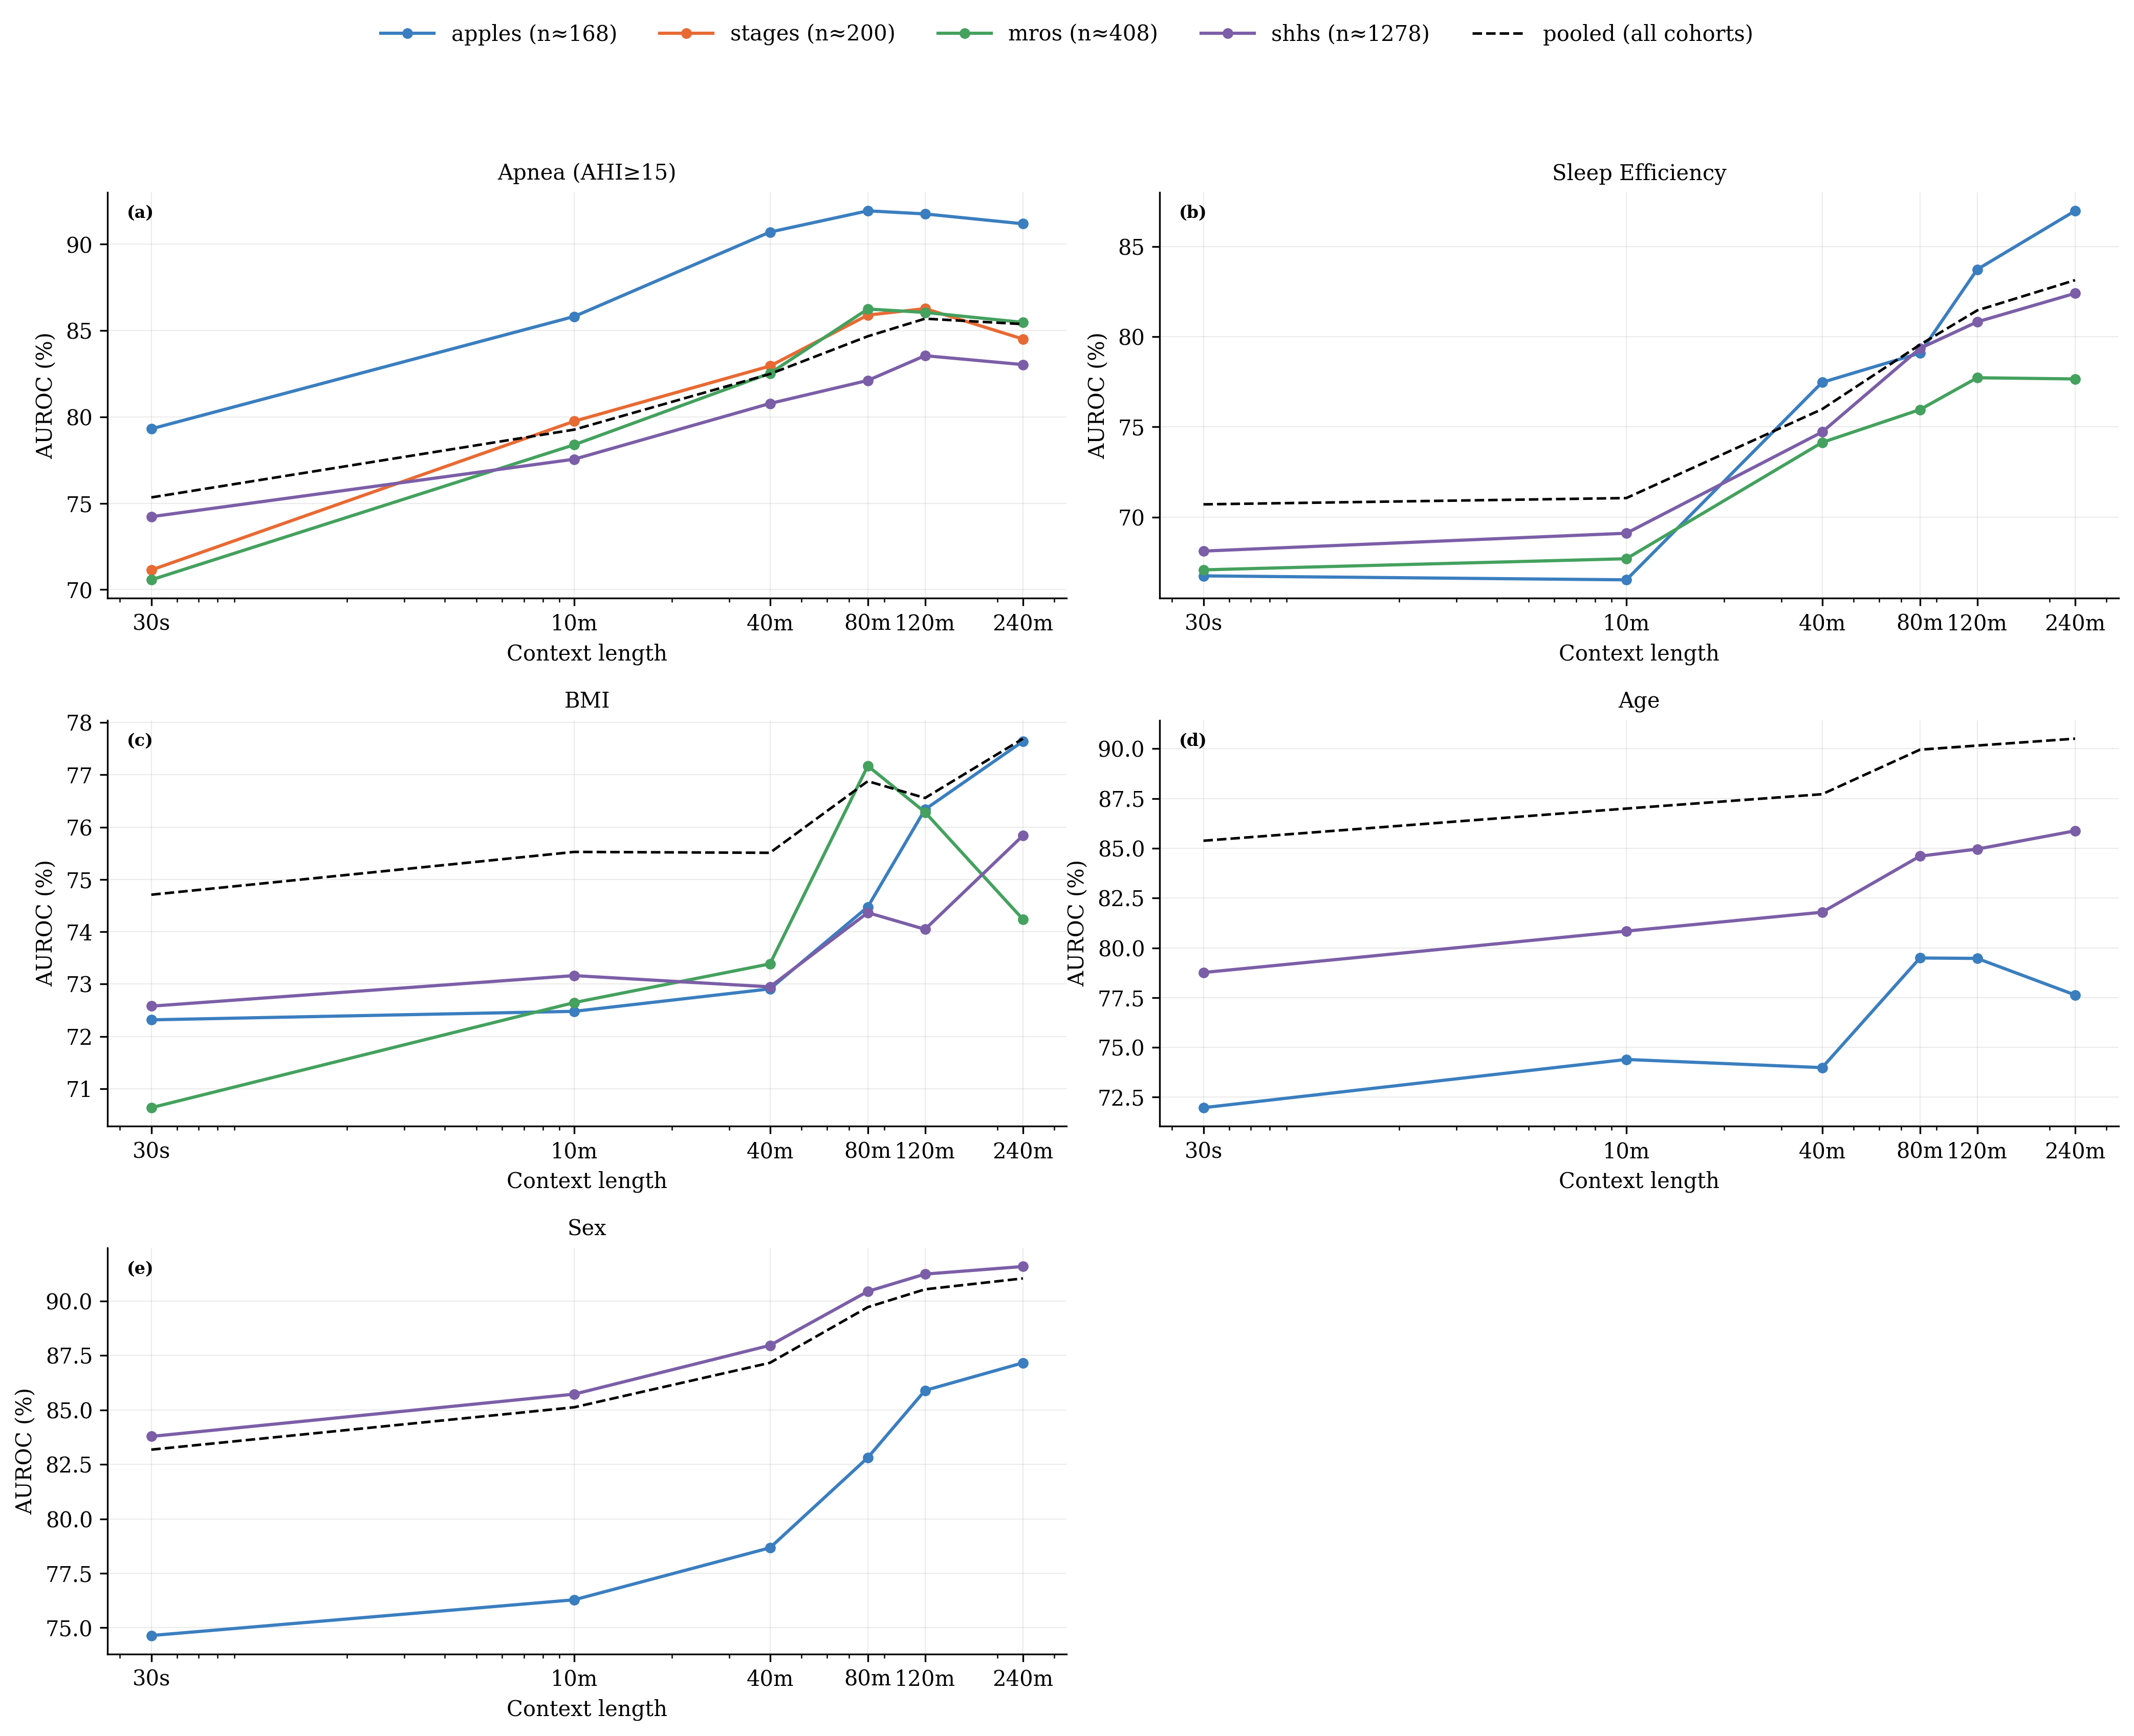

In [11]:
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(FULL_W * 2, N_ROWS * 3.0+2))
axes_flat = axes.flatten()

for i, (ax, task) in enumerate(zip(axes_flat, TASKS)):
    panels.cross_cohort_panel(ax, cohort_df, task, cohorts=COHORTS, legend=False)
    ax.set_title(TASK_LABEL.get(task, task), fontsize=FONT_TITLE)
    add_panel_label(ax, f"({chr(97+i)})")

for ax in axes_flat[len(TASKS):]:
    ax.set_visible(False)

# Single shared legend at the top
_h, _l = axes_flat[0].get_legend_handles_labels()
fig.legend(_h, _l, loc="upper center", ncol=len(_h),
           fontsize=FONT_ANNOT, frameon=False,
           bbox_to_anchor=(0.5, 1.03), handlelength=2.5)

fig.tight_layout(h_pad=1.2, w_pad=1.0, rect=[0, 0, 1, 0.95])
plt.show()


In [12]:
# ── Run when figure looks good ──────────────────────────────
save_figure(fig, FINAL_OUT, "sfig1_cross_cohort")
import shutil
shutil.copy(FINAL_OUT / "sfig1_cross_cohort.pdf",
            WORKSPACE_ROOT / "npj_digital_medicine_submission" / "sfig1_cross_cohort.pdf")
print("Saved + copied → npj_digital_medicine_submission/sfig1_cross_cohort.pdf")


  saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/final_npj/sfig1_cross_cohort.pdf
Saved + copied → npj_digital_medicine_submission/sfig1_cross_cohort.pdf
